In [1]:
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scikit_posthocs as sp
from utils import *

In [2]:
results = pd.concat([pd.read_csv(f).assign(file=f) for f in glob.glob("results/*.csv")]).assign(
    configuration=lambda df: df["file"].apply(lambda row: row[-9:-8]),
    scenario=lambda df: df["file"].apply(lambda row: row[-7:-6]),
    noise_level=lambda df: df["file"].apply(lambda row: row[-5:-4])
).drop("column", axis=1)

In [3]:
results

,Best model-mean_distance,Best model-root_mean_square_distance,Best model-inner-q0.05-mean_distance,Best model-inner-q0.05-root_mean_square_distance,Best model-outer-q0.05-mean_distance,Best model-outer-q0.05-root_mean_square_distance,Best model-inner-q0.1-mean_distance,Best model-inner-q0.1-root_mean_square_distance,Best model-outer-q0.1-mean_distance,Best model-outer-q0.1-root_mean_square_distance,...,Best stacked ensemble-inner-q0.1-root_mean_square_distance,Best stacked ensemble-outer-q0.1-mean_distance,Best stacked ensemble-outer-q0.1-root_mean_square_distance,Best stacked ensemble-inner-q0.25-mean_distance,Best stacked ensemble-inner-q0.25-root_mean_square_distance,Best stacked ensemble-outer-q0.25-mean_distance,Best stacked ensemble-outer-q0.25-root_mean_square_distance,configuration,scenario,noise_level
0,1.087090,1.720104,0.760216,1.152030,4.028955,4.200362,0.525718,0.730575,3.332578,3.557926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1,1
1,0.322164,0.329404,0.322164,0.329404,NaN,NaN,0.322164,0.329404,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1,1
2,0.534130,0.670187,0.445493,0.533223,1.331867,1.390166,0.372516,0.417844,1.180587,1.243936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1,1
3,0.306051,0.309125,0.308940,0.311122,0.280046,0.290533,0.311635,0.313149,0.283714,0.292475,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1,1
4,0.176349,0.203356,0.157617,0.180032,0.344939,0.349047,0.142201,0.162374,0.312942,0.318288,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,0.161707,0.182942,0.153529,0.167830,0.235313,0.284915,0.155179,0.165767,0.187821,0.239635,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P,3,9
5,0.064018,0.080906,0.064018,0.080906,NaN,NaN,0.064018,0.080906,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P,3,9
6,0.331882,0.502234,0.239395,0.356155,1.164259,1.175064,0.167223,0.236965,0.990517,1.018128,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P,3,9
7,0.020016,0.025160,0.020016,0.025160,NaN,NaN,0.020016,0.025160,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P,3,9


In [4]:
results.describe().style

,Best model-mean_distance,Best model-root_mean_square_distance,Best model-inner-q0.05-mean_distance,Best model-inner-q0.05-root_mean_square_distance,Best model-outer-q0.05-mean_distance,Best model-outer-q0.05-root_mean_square_distance,Best model-inner-q0.1-mean_distance,Best model-inner-q0.1-root_mean_square_distance,Best model-outer-q0.1-mean_distance,Best model-outer-q0.1-root_mean_square_distance,Best model-inner-q0.25-mean_distance,Best model-inner-q0.25-root_mean_square_distance,Best model-outer-q0.25-mean_distance,Best model-outer-q0.25-root_mean_square_distance,Best basemodel-mean_distance,Best basemodel-root_mean_square_distance,Best basemodel-inner-q0.05-mean_distance,Best basemodel-inner-q0.05-root_mean_square_distance,Best basemodel-outer-q0.05-mean_distance,Best basemodel-outer-q0.05-root_mean_square_distance,Best basemodel-inner-q0.1-mean_distance,Best basemodel-inner-q0.1-root_mean_square_distance,Best basemodel-outer-q0.1-mean_distance,Best basemodel-outer-q0.1-root_mean_square_distance,Best basemodel-inner-q0.25-mean_distance,Best basemodel-inner-q0.25-root_mean_square_distance,Best basemodel-outer-q0.25-mean_distance,Best basemodel-outer-q0.25-root_mean_square_distance,All models-mean_distance,All models-root_mean_square_distance,All models-inner-q0.05-mean_distance,All models-inner-q0.05-root_mean_square_distance,All models-outer-q0.05-mean_distance,All models-outer-q0.05-root_mean_square_distance,All models-inner-q0.1-mean_distance,All models-inner-q0.1-root_mean_square_distance,All models-outer-q0.1-mean_distance,All models-outer-q0.1-root_mean_square_distance,All models-inner-q0.25-mean_distance,All models-inner-q0.25-root_mean_square_distance,All models-outer-q0.25-mean_distance,All models-outer-q0.25-root_mean_square_distance,Rashomon-mean_distance,Rashomon-root_mean_square_distance,Rashomon-inner-q0.05-mean_distance,Rashomon-inner-q0.05-root_mean_square_distance,Rashomon-outer-q0.05-mean_distance,Rashomon-outer-q0.05-root_mean_square_distance,Rashomon-inner-q0.1-mean_distance,Rashomon-inner-q0.1-root_mean_square_distance,Rashomon-outer-q0.1-mean_distance,Rashomon-outer-q0.1-root_mean_square_distance,Rashomon-inner-q0.25-mean_distance,Rashomon-inner-q0.25-root_mean_square_distance,Rashomon-outer-q0.25-mean_distance,Rashomon-outer-q0.25-root_mean_square_distance,Best of Family-mean_distance,Best of Family-root_mean_square_distance,Best of Family-inner-q0.05-mean_distance,Best of Family-inner-q0.05-root_mean_square_distance,Best of Family-outer-q0.05-mean_distance,Best of Family-outer-q0.05-root_mean_square_distance,Best of Family-inner-q0.1-mean_distance,Best of Family-inner-q0.1-root_mean_square_distance,Best of Family-outer-q0.1-mean_distance,Best of Family-outer-q0.1-root_mean_square_distance,Best of Family-inner-q0.25-mean_distance,Best of Family-inner-q0.25-root_mean_square_distance,Best of Family-outer-q0.25-mean_distance,Best of Family-outer-q0.25-root_mean_square_distance,Best of Family models ∩ Rashomon models-mean_distance,Best of Family models ∩ Rashomon models-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.05-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.05-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.05-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.05-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.1-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.1-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.1-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.1-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.25-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.25-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.25-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.25-root_mean_square_distance,Best stacked ensemble-mean_distance,Best stacked ensemble-root_me

In [5]:
for group_by in [["configuration"], ["scenario"], ["noise_level"], ["scenario", "noise_level"], ["configuration", "scenario", "noise_level"]]:
    for metric in ["mean_distance", "root_mean_square_distance"]:
        res = results[[c for c in results.columns if metric in c and "inner" not in c and "outer" not in c] + group_by]
        display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        res = results[[c for c in results.columns if metric in c and "0.25" in c and "outer" not in c] + group_by]
        display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        res = results[[c for c in results.columns if metric in c and "0.1" in c and "outer" not in c] + group_by]
        display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        # res = results[[c for c in results.columns if metric in c and "0.05" in c and "outer" not in c] + group_by]
        # display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        # res = results[[c for c in results.columns if metric in c and "0.25" in c and "outer" in c] + group_by]
        # display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        res = results[[c for c in results.columns if metric in c and "0.1" in c and "outer" in c] + group_by]
        display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        res = results[[c for c in results.columns if metric in c and "0.05" in c and "outer" in c] + group_by]
        display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))

,Best model-mean_distance,Best basemodel-mean_distance,All models-mean_distance,Rashomon-mean_distance,Best of Family-mean_distance,Best of Family models ∩ Rashomon models-mean_distance,Best stacked ensemble-mean_distance
configuration,,,,,,,
A,0.209343,0.209343,0.190460,0.163123,0.205546,0.165655,nan
B,0.159029,0.181947,0.217928,0.169836,0.196751,0.156836,0.148733
C,0.162719,0.179604,0.219759,0.171914,0.194746,0.161700,0.162719
D,0.170296,0.201638,0.222929,0.171021,0.195887,0.159023,0.170296
E,0.181100,0.181100,0.195054,0.172810,0.207810,0.168925,nan
F,0.216219,0.216219,0.190107,0.166002,0.197874,0.161653,nan
G,0.235624,0.244551,0.261022,0.188704,0.205460,0.170219,0.115972
H,0.154564,0.247678,0.282388,0.177211,0.192947,0.164699,0.154564
I,0.165559,0.165559,0.185136,0.167697,0.199129,0.167290,nan


,Best model-inner-q0.25-mean_distance,Best basemodel-inner-q0.25-mean_distance,All models-inner-q0.25-mean_distance,Rashomon-inner-q0.25-mean_distance,Best of Family-inner-q0.25-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.25-mean_distance,Best stacked ensemble-inner-q0.25-mean_distance
configuration,,,,,,,
A,0.113488,0.113488,0.082942,0.066389,0.084272,0.077758,nan
B,0.073974,0.091949,0.114683,0.080645,0.081443,0.072502,0.070964
C,0.082308,0.088593,0.115499,0.086774,0.083501,0.078726,0.082308
D,0.092633,0.106726,0.119184,0.086010,0.084353,0.077512,0.092633
E,0.090483,0.090483,0.081717,0.071720,0.089917,0.083087,nan
F,0.132970,0.132970,0.081936,0.070292,0.084377,0.083302,nan
G,0.150175,0.152560,0.149846,0.092103,0.093776,0.092458,0.081789
H,0.082437,0.165244,0.172444,0.090815,0.090453,0.092930,0.082437
I,0.079340,0.079340,0.076797,0.069268,0.084048,0.084354,nan


,Best model-inner-q0.1-mean_distance,Best basemodel-inner-q0.1-mean_distance,All models-inner-q0.1-mean_distance,Rashomon-inner-q0.1-mean_distance,Best of Family-inner-q0.1-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.1-mean_distance,Best stacked ensemble-inner-q0.1-mean_distance
configuration,,,,,,,
A,0.150091,0.150091,0.119089,0.096583,0.132533,0.106279,nan
B,0.102805,0.126724,0.149708,0.107726,0.126260,0.100012,0.094095
C,0.108881,0.123937,0.151404,0.113030,0.126091,0.105826,0.108881
D,0.117840,0.142949,0.154848,0.112490,0.127169,0.103754,0.117840
E,0.125603,0.125603,0.120177,0.102337,0.136089,0.110610,nan
F,0.165994,0.165994,0.118617,0.099733,0.128770,0.107800,nan
G,0.184615,0.190258,0.191139,0.123385,0.137367,0.116944,0.095239
H,0.105816,0.196819,0.213516,0.118489,0.128978,0.115263,0.105816
I,0.106245,0.106245,0.112506,0.099013,0.127907,0.110185,nan


,Best model-outer-q0.1-mean_distance,Best basemodel-outer-q0.1-mean_distance,All models-outer-q0.1-mean_distance,Rashomon-outer-q0.1-mean_distance,Best of Family-outer-q0.1-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.1-mean_distance,Best stacked ensemble-outer-q0.1-mean_distance
configuration,,,,,,,
A,0.626527,0.626527,0.681962,0.620356,0.718841,0.578715,nan
B,0.552828,0.574645,0.687075,0.596297,0.692001,0.552632,0.527176
C,0.538819,0.575437,0.689629,0.577678,0.677169,0.551606,0.538819
D,0.535862,0.617315,0.690943,0.573794,0.678693,0.543832,0.535862
E,0.574638,0.574638,0.709998,0.655921,0.712098,0.574514,nan
F,0.566782,0.566782,0.681660,0.620867,0.683743,0.535258,nan
G,0.595024,0.626134,0.739550,0.635414,0.684766,0.540753,0.288897
H,0.495043,0.601372,0.755627,0.579930,0.641448,0.508300,0.495043
I,0.580005,0.580005,0.685974,0.640963,0.697628,0.563916,nan


,Best model-outer-q0.05-mean_distance,Best basemodel-outer-q0.05-mean_distance,All models-outer-q0.05-mean_distance,Rashomon-outer-q0.05-mean_distance,Best of Family-outer-q0.05-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.05-mean_distance,Best stacked ensemble-outer-q0.05-mean_distance
configuration,,,,,,,
A,0.740164,0.740164,0.814140,0.750485,0.838675,0.700071,nan
B,0.665417,0.693465,0.814904,0.722998,0.811023,0.671622,0.641440
C,0.649421,0.694759,0.816192,0.699244,0.795163,0.667552,0.649421
D,0.644470,0.730277,0.817394,0.695051,0.796638,0.659904,0.644470
E,0.693632,0.693632,0.848709,0.791842,0.831418,0.695045,nan
F,0.655065,0.655065,0.812768,0.746513,0.799714,0.648757,nan
G,0.678670,0.713286,0.866609,0.757412,0.799567,0.653567,0.331613
H,0.594783,0.686966,0.881162,0.693978,0.753070,0.614713,0.594783
I,0.717946,0.717946,0.825892,0.780734,0.820247,0.686739,nan


...

,Best model-root_mean_square_distance,Best basemodel-root_mean_square_distance,All models-root_mean_square_distance,Rashomon-root_mean_square_distance,Best of Family-root_mean_square_distance,Best of Family models ∩ Rashomon models-root_mean_square_distance,Best stacked ensemble-root_mean_square_distance
noise_level,,,,,,,
1,0.219533,0.226470,0.283706,0.207151,0.260780,0.184948,0.184166
4,0.301678,0.309452,0.329986,0.287738,0.313531,0.282719,0.263898
9,0.305335,0.325267,0.341320,0.317406,0.316623,0.281758,0.253832


,Best model-inner-q0.25-root_mean_square_distance,Best basemodel-inner-q0.25-root_mean_square_distance,All models-inner-q0.25-root_mean_square_distance,Rashomon-inner-q0.25-root_mean_square_distance,Best of Family-inner-q0.25-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.25-root_mean_square_distance,Best stacked ensemble-inner-q0.25-root_mean_square_distance
noise_level,,,,,,,
1,0.081141,0.090279,0.102389,0.054208,0.079333,0.061778,0.058547
4,0.144643,0.154023,0.133973,0.108817,0.121395,0.126778,0.116206
9,0.131663,0.140083,0.121236,0.109117,0.106248,0.100052,0.108495


,Best model-inner-q0.1-root_mean_square_distance,Best basemodel-inner-q0.1-root_mean_square_distance,All models-inner-q0.1-root_mean_square_distance,Rashomon-inner-q0.1-root_mean_square_distance,Best of Family-inner-q0.1-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.1-root_mean_square_distance,Best stacked ensemble-inner-q0.1-root_mean_square_distance
noise_level,,,,,,,
1,0.121005,0.130983,0.157696,0.091961,0.148965,0.091666,0.090695
4,0.196081,0.206187,0.198590,0.163042,0.196209,0.176663,0.164481
9,0.205192,0.221941,0.205430,0.187066,0.190283,0.165331,0.162004


,Best model-outer-q0.1-root_mean_square_distance,Best basemodel-outer-q0.1-root_mean_square_distance,All models-outer-q0.1-root_mean_square_distance,Rashomon-outer-q0.1-root_mean_square_distance,Best of Family-outer-q0.1-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.1-root_mean_square_distance,Best stacked ensemble-outer-q0.1-root_mean_square_distance
noise_level,,,,,,,
1,0.573259,0.576190,0.732578,0.590978,0.695354,0.506005,0.502713
4,0.700184,0.705456,0.806002,0.729622,0.767947,0.673972,0.639264
9,0.724643,0.767145,0.869998,0.816560,0.819776,0.725449,0.615996


,Best model-outer-q0.05-root_mean_square_distance,Best basemodel-outer-q0.05-root_mean_square_distance,All models-outer-q0.05-root_mean_square_distance,Rashomon-outer-q0.05-root_mean_square_distance,Best of Family-outer-q0.05-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.05-root_mean_square_distance,Best stacked ensemble-outer-q0.05-root_mean_square_distance
noise_level,,,,,,,
1,0.680682,0.682159,0.856614,0.709279,0.806213,0.614133,0.606121
4,0.806832,0.813282,0.928926,0.847055,0.877105,0.778378,0.740263
9,0.817956,0.860120,1.001227,0.940949,0.933516,0.837932,0.709022


In [6]:
header("Ranks", "=")
group_by = ["configuration", "scenario", "noise_level"]
for metric in ["mean_distance", "root_mean_square_distance"]:
    header(metric)
    res = results[[c for c in results.columns if metric in c and "0." not in c and "outer" not in c] + group_by]
    display(res.groupby(group_by).mean().rank(axis=1).describe().style.background_gradient(cmap='RdYlGn_r', axis=1, subset=(["mean", "50%"],slice(None))))
    res = results[[c for c in results.columns if metric in c and "0.25" in c and "outer" not in c] + group_by]
    display(res.groupby(group_by).mean().rank(axis=1).describe().style.background_gradient(cmap='RdYlGn_r', axis=1, subset=(["mean", "50%"],slice(None))))
    res = results[[c for c in results.columns if metric in c and "0.25" in c and "outer"  in c] + group_by]
    display(res.groupby(group_by).mean().rank(axis=1).describe().style.background_gradient(cmap='RdYlGn_r', axis=1, subset=(["mean", "50%"],slice(None))))


Ranks
=====

mean_distance
-------------


,Best model-mean_distance,Best basemodel-mean_distance,All models-mean_distance,Rashomon-mean_distance,Best of Family-mean_distance,Best of Family models ∩ Rashomon models-mean_distance,Best stacked ensemble-mean_distance
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,35.000000
mean,3.489583,4.107639,4.763889,2.666667,4.555556,2.493056,2.571429
std,1.567222,1.767187,1.564403,1.458038,1.647324,1.344486,1.261085
min,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.500000
25%,1.500000,2.500000,4.000000,1.000000,4.000000,1.000000,1.500000
50%,3.500000,4.500000,5.000000,2.000000,5.000000,2.000000,2.500000
75%,5.500000,5.500000,6.000000,4.000000,6.000000,3.125000,3.500000
max,5.500000,7.000000,7.000000,6.000000,7.000000,6.000000,5.500000


,Best model-inner-q0.25-mean_distance,Best basemodel-inner-q0.25-mean_distance,All models-inner-q0.25-mean_distance,Rashomon-inner-q0.25-mean_distance,Best of Family-inner-q0.25-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.25-mean_distance,Best stacked ensemble-inner-q0.25-mean_distance
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,35.000000
mean,4.003472,4.559028,4.201389,2.270833,3.923611,3.034722,2.914286
std,1.466999,1.487120,1.784078,1.754988,1.599081,1.587377,1.467720
min,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.500000
25%,3.500000,3.500000,3.000000,1.000000,3.000000,2.000000,1.500000
50%,4.500000,5.000000,4.000000,1.000000,4.000000,3.000000,2.500000
75%,5.500000,5.500000,6.000000,3.000000,5.000000,4.000000,4.000000
max,5.500000,7.000000,7.000000,7.000000,7.000000,6.000000,5.500000


,Best model-outer-q0.25-mean_distance,Best basemodel-outer-q0.25-mean_distance,All models-outer-q0.25-mean_distance,Rashomon-outer-q0.25-mean_distance,Best of Family-outer-q0.25-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.25-mean_distance,Best stacked ensemble-outer-q0.25-mean_distance
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,35.000000
mean,3.461806,3.961806,4.861111,2.972222,4.524306,2.253472,2.742857
std,1.593343,1.883012,1.361874,1.295201,1.846685,1.259921,1.139991
min,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.500000
25%,1.500000,2.500000,4.000000,2.000000,3.500000,1.000000,1.500000
50%,3.500000,4.500000,5.000000,3.000000,5.000000,2.000000,3.000000
75%,5.500000,5.500000,6.000000,4.000000,6.000000,3.000000,3.500000
max,5.500000,7.000000,7.000000,5.000000,7.000000,5.500000,4.500000



root_mean_square_distance
-------------------------


,Best model-root_mean_square_distance,Best basemodel-root_mean_square_distance,All models-root_mean_square_distance,Rashomon-root_mean_square_distance,Best of Family-root_mean_square_distance,Best of Family models ∩ Rashomon models-root_mean_square_distance,Best stacked ensemble-root_mean_square_distance
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,35.000000
mean,3.454861,4.038194,5.069444,3.020833,4.208333,2.312500,2.457143
std,1.621440,1.818783,1.346598,1.460284,1.739604,1.284489,1.165506
min,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.500000
25%,1.500000,2.500000,4.000000,2.000000,3.000000,1.000000,1.500000
50%,3.500000,4.500000,5.000000,3.000000,4.000000,2.000000,1.500000
75%,5.500000,5.500000,6.000000,4.000000,6.000000,3.000000,3.500000
max,5.500000,7.000000,7.000000,6.000000,7.000000,5.500000,4.500000


,Best model-inner-q0.25-root_mean_square_distance,Best basemodel-inner-q0.25-root_mean_square_distance,All models-inner-q0.25-root_mean_square_distance,Rashomon-inner-q0.25-root_mean_square_distance,Best of Family-inner-q0.25-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.25-root_mean_square_distance,Best stacked ensemble-inner-q0.25-root_mean_square_distance
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,35.000000
mean,3.982639,4.565972,4.215278,2.215278,3.982639,3.031250,2.914286
std,1.447705,1.465508,1.798069,1.718526,1.543556,1.639993,1.427079
min,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.500000
25%,3.500000,3.500000,3.000000,1.000000,3.000000,2.000000,1.500000
50%,4.500000,5.000000,4.000000,1.000000,4.000000,3.000000,2.500000
75%,5.500000,5.500000,6.000000,3.000000,5.500000,4.000000,4.500000
max,5.500000,7.000000,7.000000,7.000000,7.000000,6.000000,5.500000


,Best model-outer-q0.25-root_mean_square_distance,Best basemodel-outer-q0.25-root_mean_square_distance,All models-outer-q0.25-root_mean_square_distance,Rashomon-outer-q0.25-root_mean_square_distance,Best of Family-outer-q0.25-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.25-root_mean_square_distance,Best stacked ensemble-outer-q0.25-root_mean_square_distance
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,35.000000
mean,3.399306,3.892361,5.020833,3.270833,4.156250,2.302083,2.714286
std,1.610260,1.967537,1.298028,1.339130,1.917411,1.271279,0.964714
min,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.500000
25%,1.500000,1.500000,4.000000,2.000000,2.000000,1.000000,1.500000
50%,3.500000,3.500000,5.000000,3.000000,5.000000,2.000000,2.500000
75%,5.500000,5.500000,6.000000,4.000000,6.000000,3.000000,3.500000
max,5.500000,7.000000,7.000000,6.000000,7.000000,6.000000,4.500000


---
# Critical difference diagram

In [7]:
melted = results.melt(["configuration", "scenario", "noise_level", "file"]).assign(
    model = lambda df: df.variable.apply(lambda s: s.split("-")[0]), 
    metric = lambda df: df.variable.apply(lambda s: s.split("-")[-1]), 
    part = lambda df: df.variable.apply(lambda s: "-".join(s.split("-")[1:-1])).str.replace("^$","full", regex=True), 
)
melted

,configuration,scenario,noise_level,file,variable,value,model,metric,part
0,A,1,1,results/A_1_1.csv,Best model-mean_distance,1.087090,Best model,mean_distance,full
1,A,1,1,results/A_1_1.csv,Best model-mean_distance,0.322164,Best model,mean_distance,full
2,A,1,1,results/A_1_1.csv,Best model-mean_distance,0.534130,Best model,mean_distance,full
3,A,1,1,results/A_1_1.csv,Best model-mean_distance,0.306051,Best model,mean_distance,full
4,A,1,1,results/A_1_1.csv,Best model-mean_distance,0.176349,Best model,mean_distance,full
...,...,...,...,...,...,...,...,...,...
127003,P,3,9,results/P_3_9.csv,Best stacked ensemble-outer-q0.25-root_mean_sq...,NaN,Best stacked ensemble,root_mean_square_distance,outer-q0.25
127004,P,3,9,results/P_3_9.csv,Best stacked ensemble-outer-q0.25-root_mean_sq...,NaN,Best stacked ensemble,root_mean_square_distance,outer-q0.25
127005,P,3,9,results/P_3_9.csv,Best stacked ensemble-outer-q0.25-root_mean_sq...,NaN,Best stacked ensemble,root_mean_square_distance,outer-q0.25
127006,P,3,9,results/P_3_9.csv,Best stacked ensemble-outer-q0.25-root_mean_sq...,NaN,Best stacked ensemble,root_mean_square_distance,outer-q0.25



Avg. ranks - full range
model
All models                                 0.569973
Best basemodel                             0.551541
Best model                                 0.524890
Best of Family                             0.472734
Best of Family models ∩ Rashomon models    0.472205
Best stacked ensemble                      0.458050
Rashomon                                   0.474408
Name: value, dtype: float64


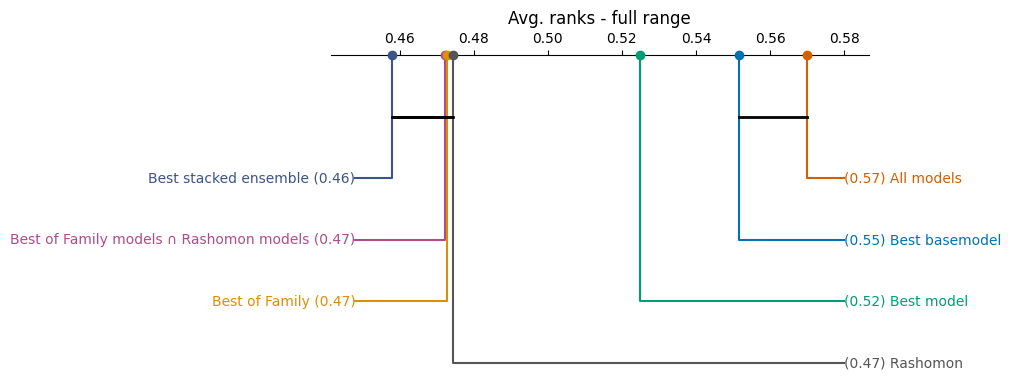

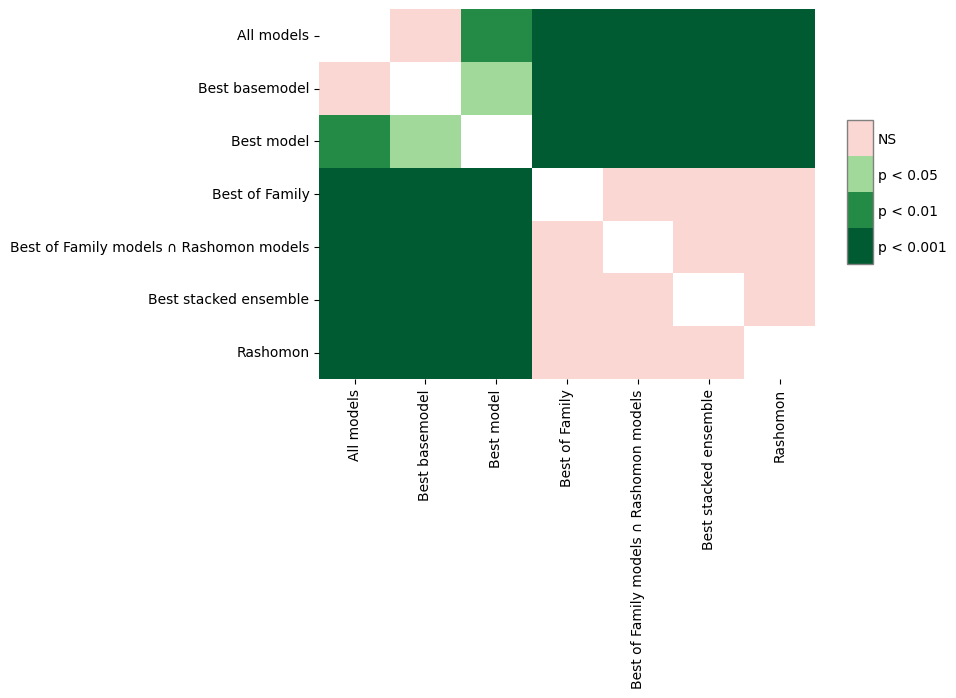


Avg. ranks - inner quartiles
model
All models                                 0.567226
Best basemodel                             0.589871
Best model                                 0.552772
Best of Family                             0.461240
Best of Family models ∩ Rashomon models    0.462128
Best stacked ensemble                      0.450542
Rashomon                                   0.434340
Name: value, dtype: float64


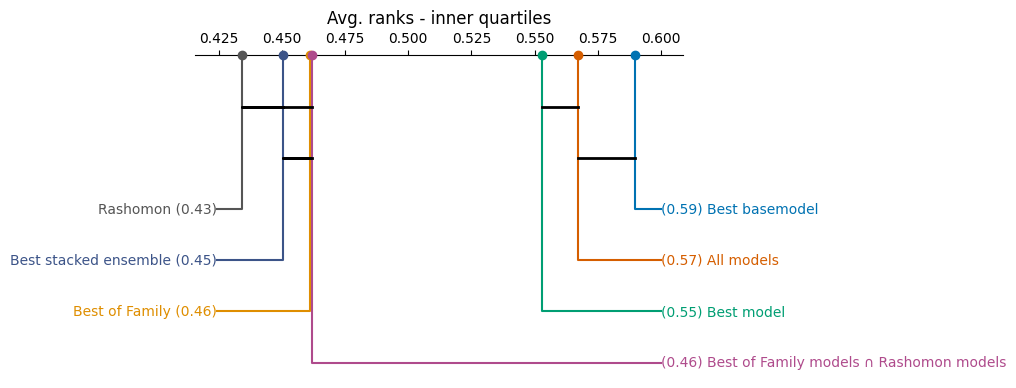

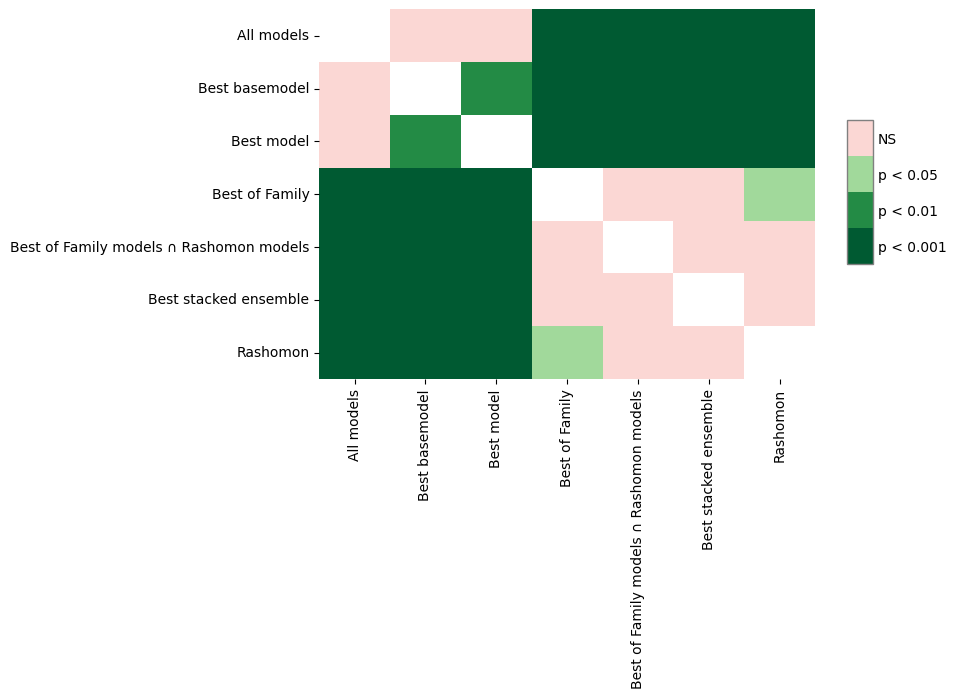


Avg. ranks - outer quartiles
model
All models                                 0.568733
Best basemodel                             0.555551
Best model                                 0.525541
Best of Family                             0.481909
Best of Family models ∩ Rashomon models    0.469430
Best stacked ensemble                      0.460771
Rashomon                                   0.491705
Name: value, dtype: float64


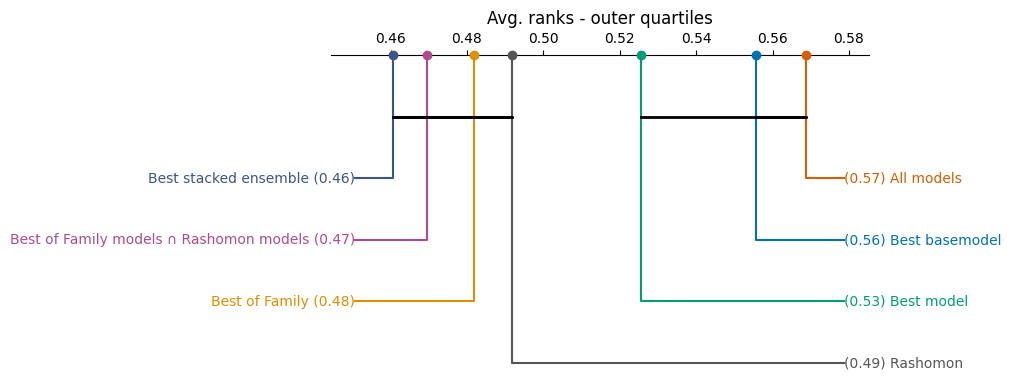

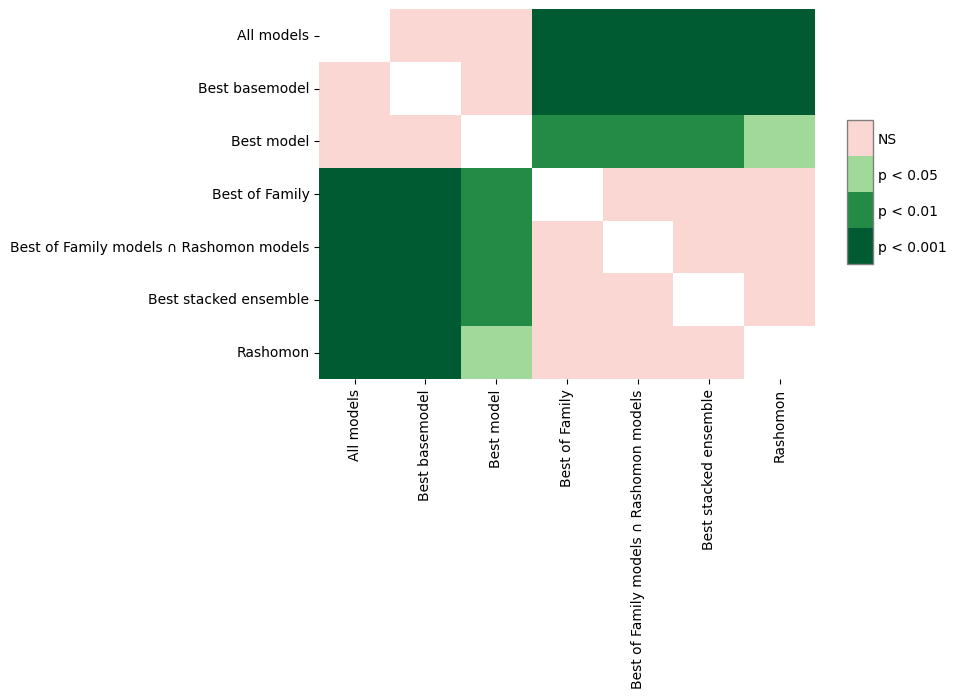


Avg. ranks - full range (noise_level == 1)
model
All models                                 0.615030
Best basemodel                             0.540445
Best model                                 0.510793
Best of Family                             0.491782
Best of Family models ∩ Rashomon models    0.456625
Best stacked ensemble                      0.445246
Rashomon                                   0.453428
Name: value, dtype: float64


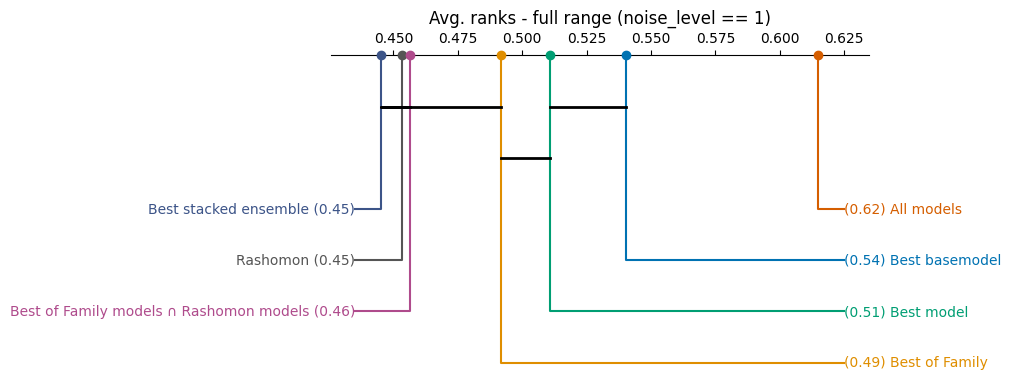

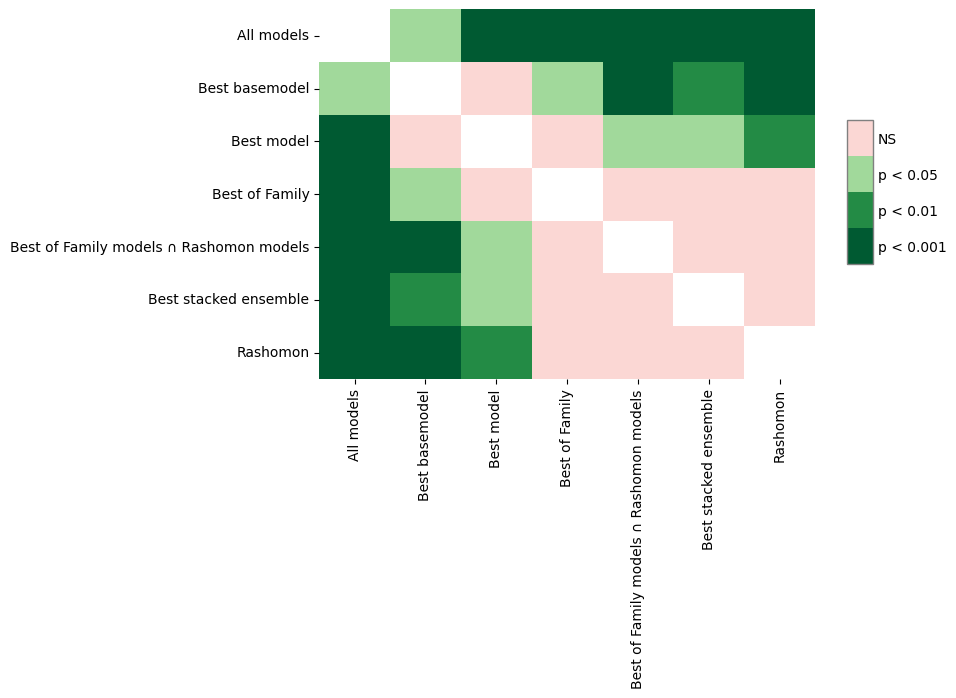


Avg. ranks - inner quartiles (noise_level == 1)
model
All models                                 0.624982
Best basemodel                             0.577702
Best model                                 0.536036
Best of Family                             0.483576
Best of Family models ∩ Rashomon models    0.460201
Best stacked ensemble                      0.435305
Rashomon                                   0.387885
Name: value, dtype: float64


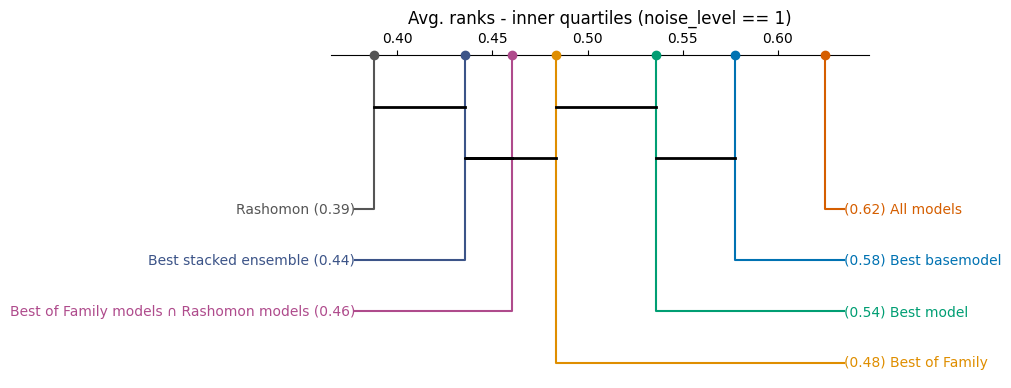

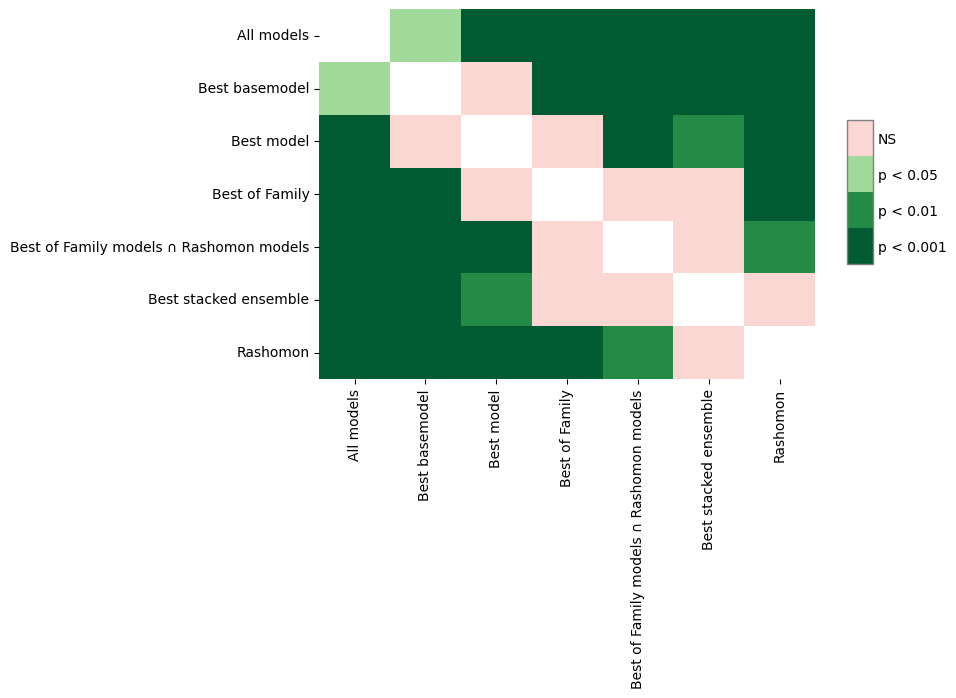


Avg. ranks - outer quartiles (noise_level == 1)
model
All models                                 0.605434
Best basemodel                             0.544064
Best model                                 0.513558
Best of Family                             0.495288
Best of Family models ∩ Rashomon models    0.455178
Best stacked ensemble                      0.450577
Rashomon                                   0.481137
Name: value, dtype: float64


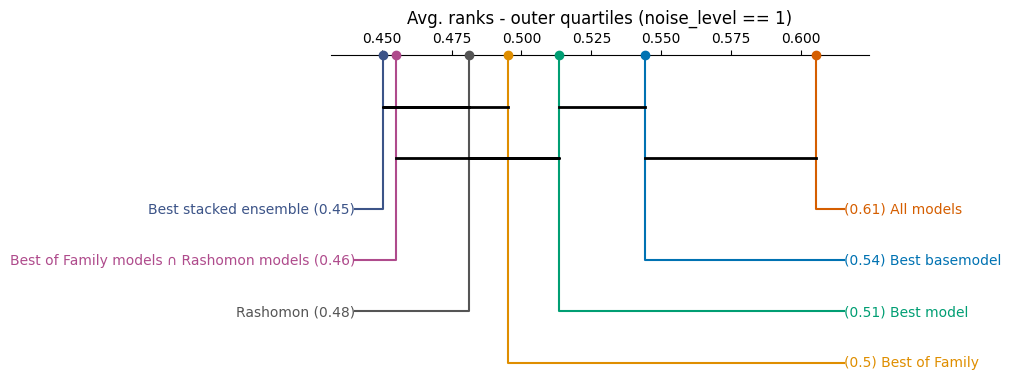

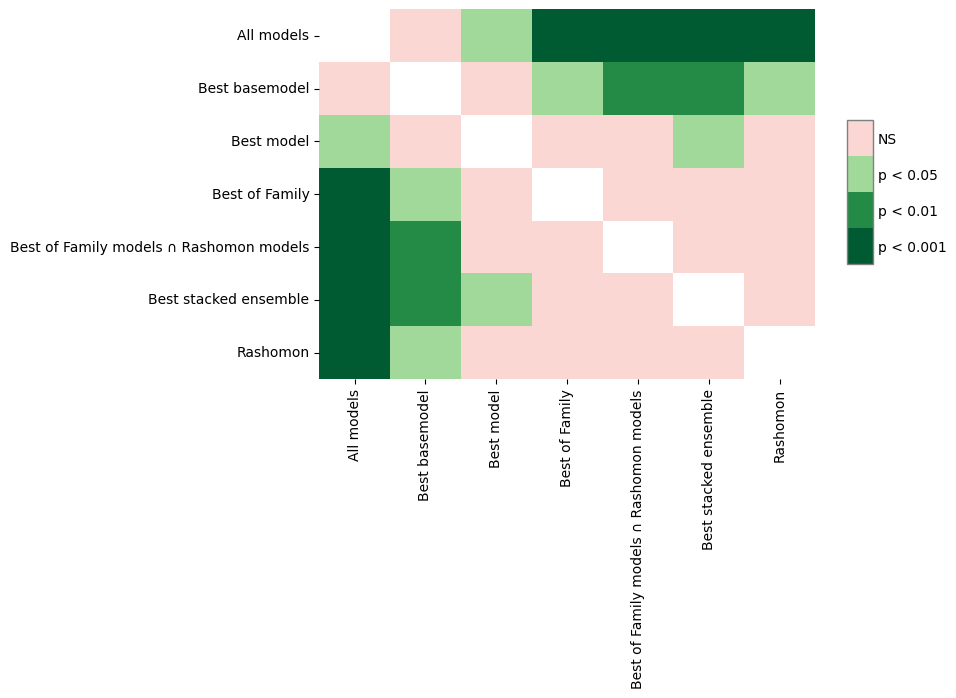


Avg. ranks - full range (noise_level == 4)
model
All models                                 0.538991
Best basemodel                             0.536829
Best model                                 0.518714
Best of Family                             0.493744
Best of Family models ∩ Rashomon models    0.518295
Best stacked ensemble                      0.460317
Rashomon                                   0.458903
Name: value, dtype: float64


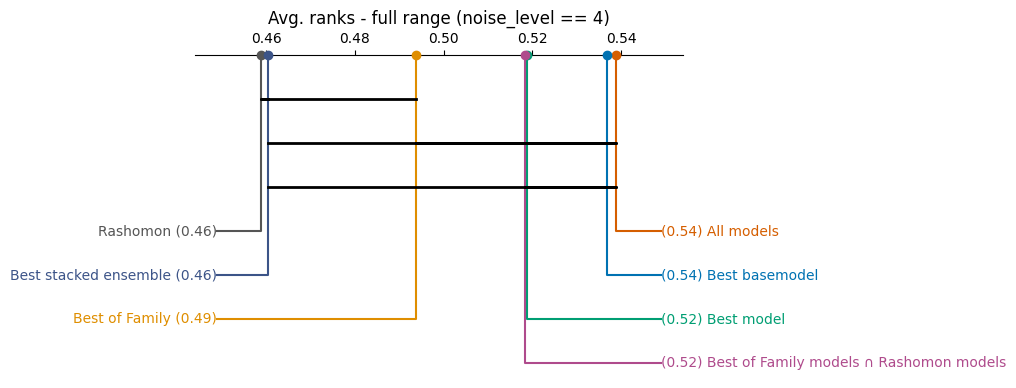

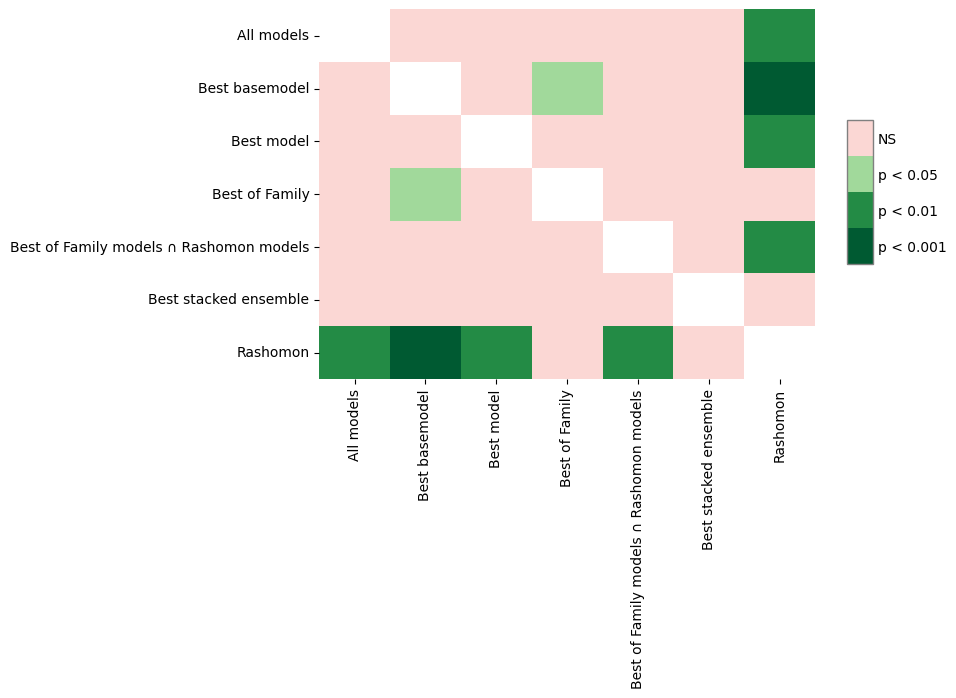


Avg. ranks - inner quartiles (noise_level == 4)
model
All models                                 0.532432
Best basemodel                             0.567399
Best model                                 0.539217
Best of Family                             0.481478
Best of Family models ∩ Rashomon models    0.515827
Best stacked ensemble                      0.452822
Rashomon                                   0.430996
Name: value, dtype: float64


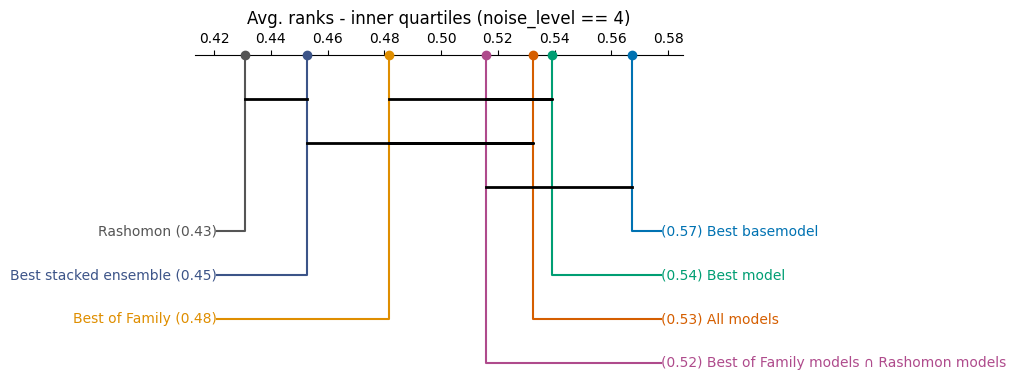

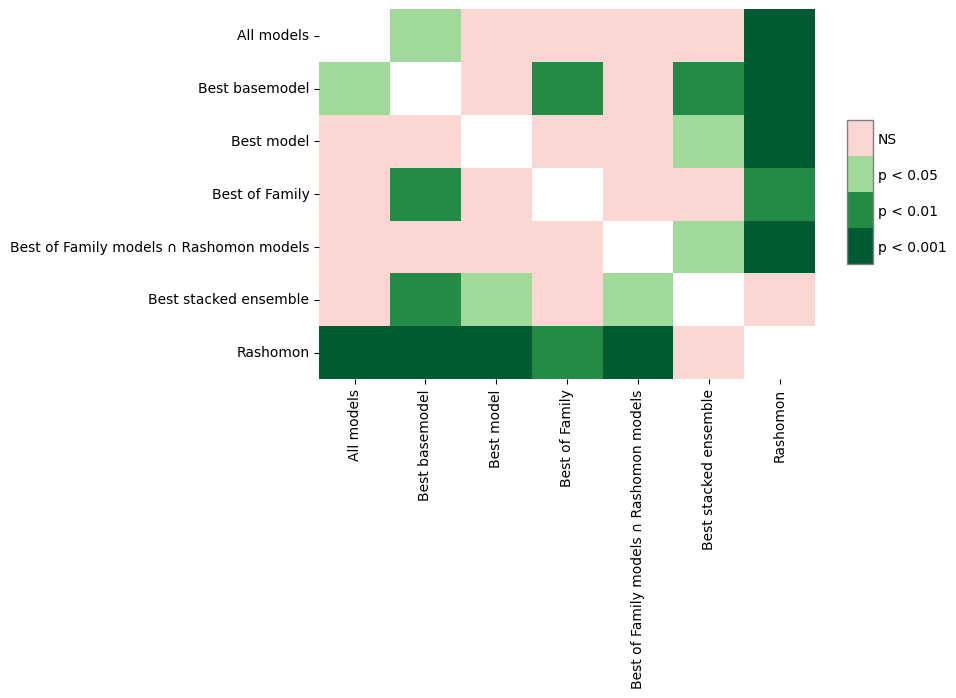


Avg. ranks - outer quartiles (noise_level == 4)
model
All models                                 0.537092
Best basemodel                             0.544946
Best model                                 0.527089
Best of Family                             0.497671
Best of Family models ∩ Rashomon models    0.511478
Best stacked ensemble                      0.477183
Rashomon                                   0.470762
Name: value, dtype: float64


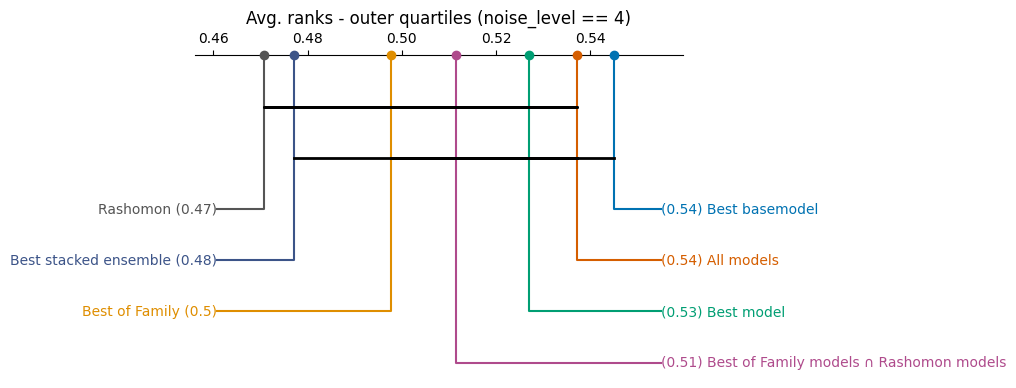

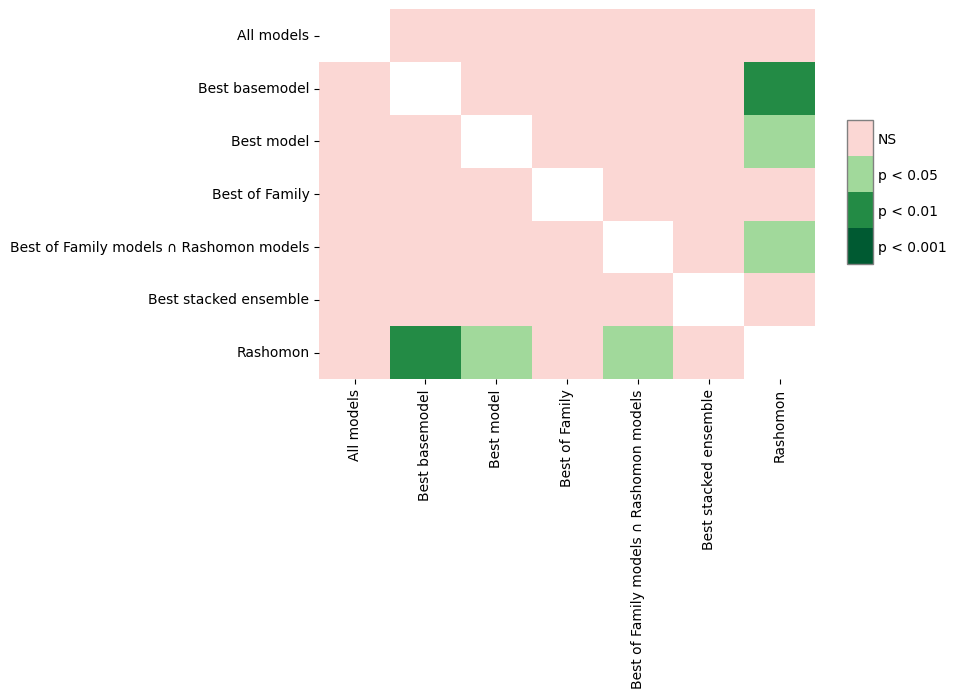


Avg. ranks - full range (noise_level == 9)
model
All models                                 0.555898
Best basemodel                             0.577350
Best model                                 0.545163
Best of Family                             0.432674
Best of Family models ∩ Rashomon models    0.441695
Best stacked ensemble                      0.467519
Rashomon                                   0.510894
Name: value, dtype: float64


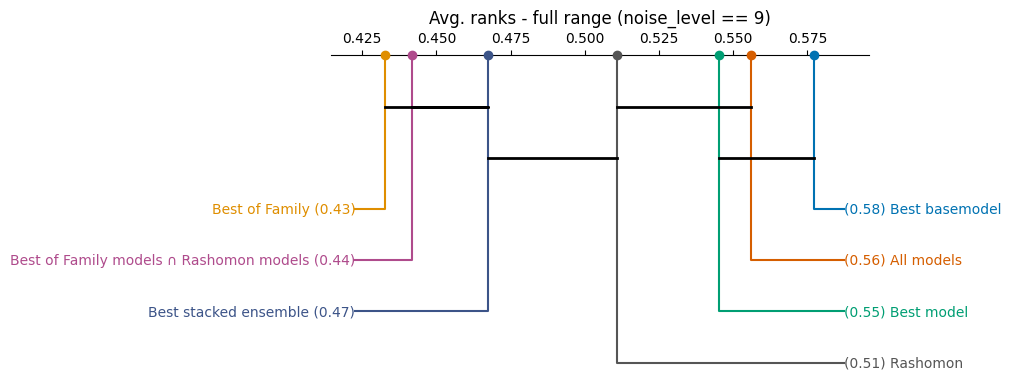

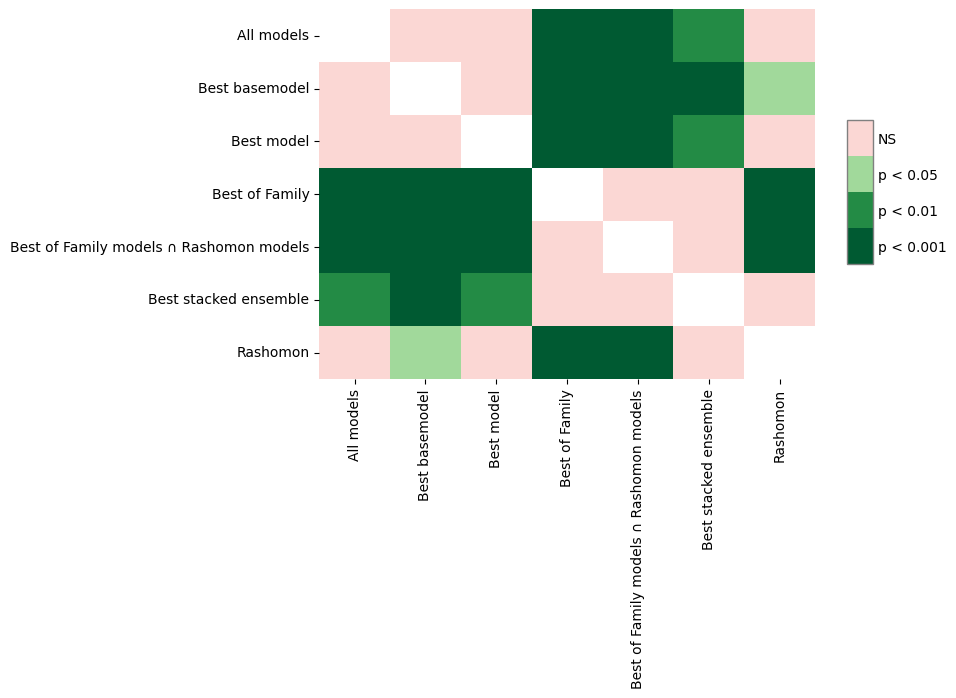


Avg. ranks - inner quartiles (noise_level == 9)
model
All models                                 0.544263
Best basemodel                             0.624510
Best model                                 0.583064
Best of Family                             0.418666
Best of Family models ∩ Rashomon models    0.410356
Best stacked ensemble                      0.462228
Rashomon                                   0.484139
Name: value, dtype: float64


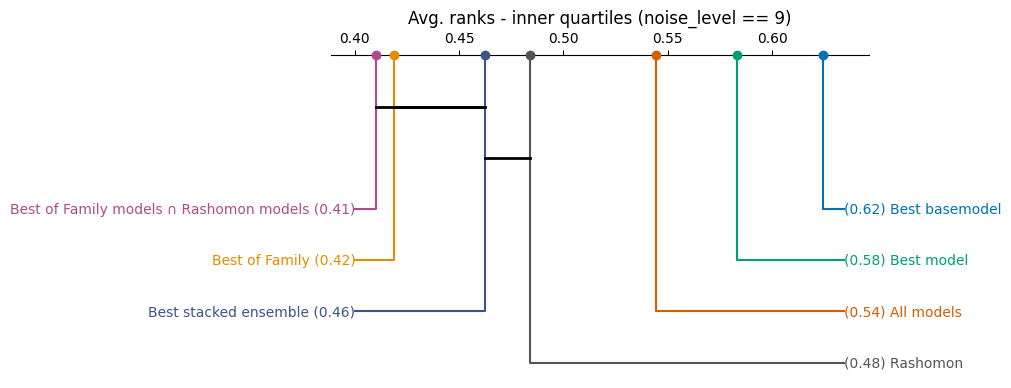

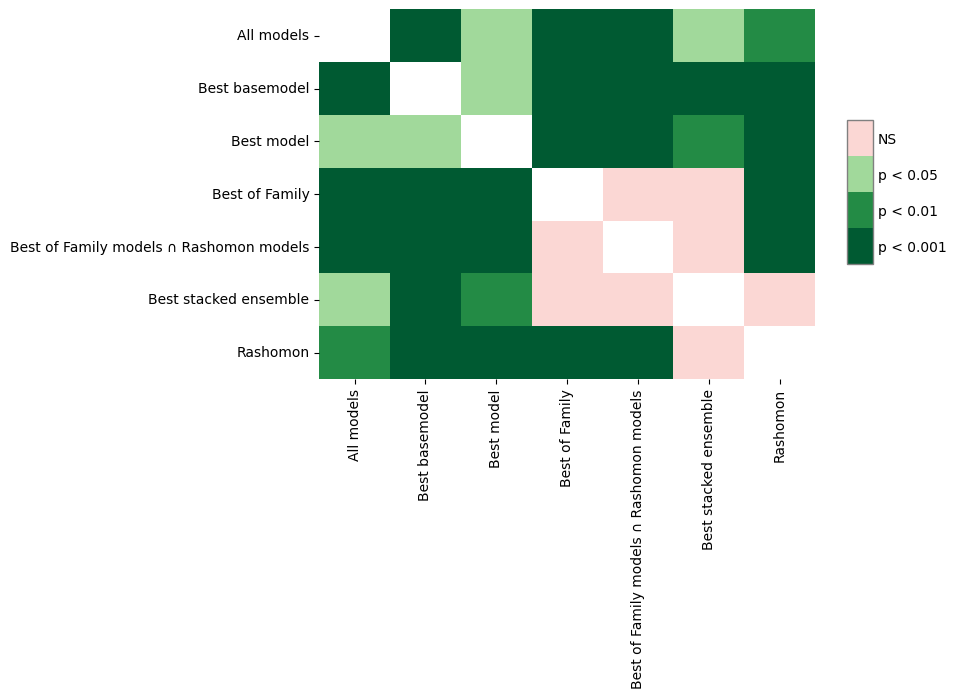


Avg. ranks - outer quartiles (noise_level == 9)
model
All models                                 0.563671
Best basemodel                             0.577643
Best model                                 0.535976
Best of Family                             0.452767
Best of Family models ∩ Rashomon models    0.441634
Best stacked ensemble                      0.453704
Rashomon                                   0.523217
Name: value, dtype: float64


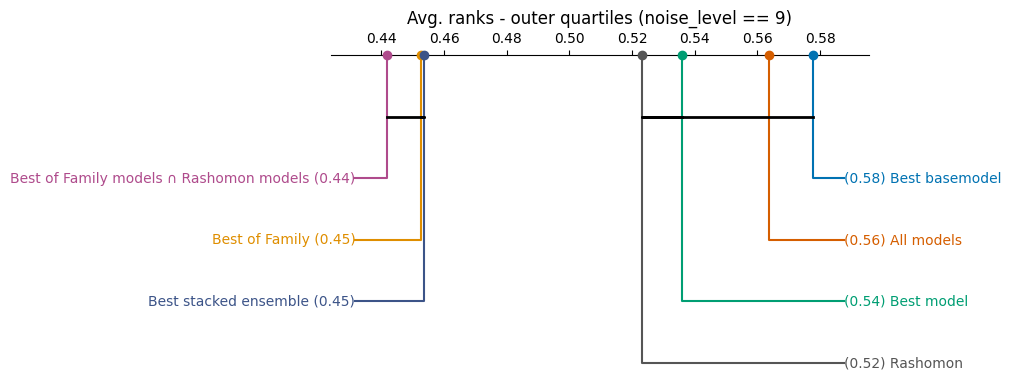

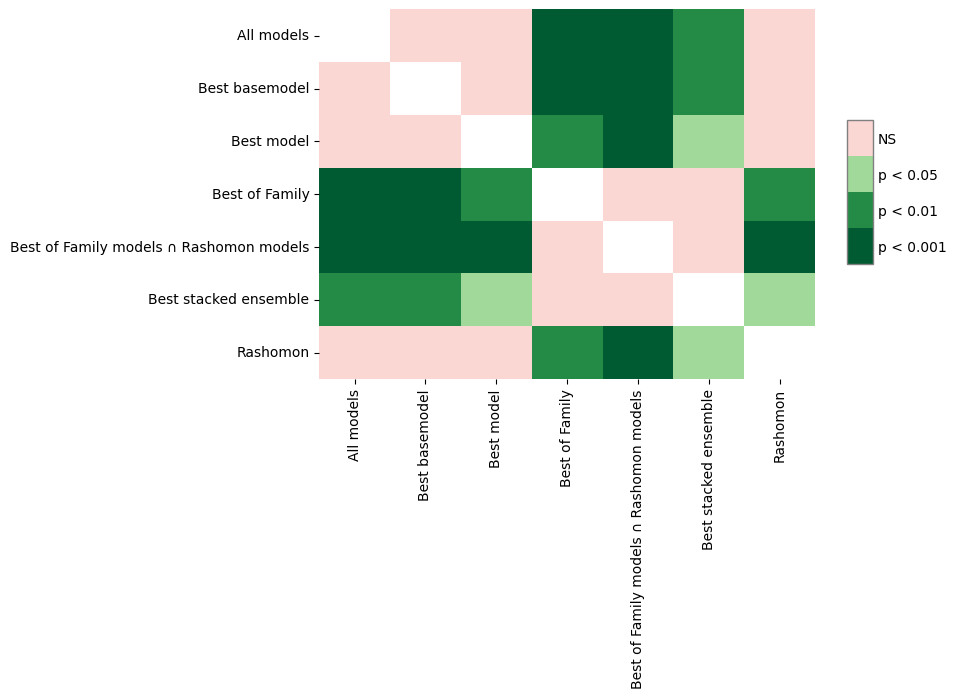

In [8]:
colors_for_strategy = {
    "All models": "#D55E00",                              # vivid orange
    "Best basemodel": "#0072B2",                          # deep blue
    "Best model": "#009E73",                              # strong teal
    "Best of Family": "#DF8E00",                          # amber gold (darker, 5.1:1)
    "Best of Family models ∩ Rashomon models": "#AF4B8C", # violet purple (5.3:1, distinct)
    "Best stacked ensemble": "#3C5488",                   # steel blue (5.6:1, unique)
    "Rashomon": "#555555"                                 # dark gray
}



def stats(subset, title, save_to=None):
    header(title, "=")
    avg_rank = subset.groupby('file').value.rank(pct=True).groupby(subset.model).mean()
    print(avg_rank)
    test_results = sp.posthoc_conover(
        subset,
        group_col='model',
        val_col='value',   
    )
    plt.figure(figsize=(10,4))
    sp.critical_difference_diagram(avg_rank, test_results, color_palette=colors_for_strategy)
    plt.title(title)
    plt.tight_layout()
    if save_to:
        plt.savefig(save_to)
    plt.show()
    sp.sign_plot(test_results)
    plt.show()


##################################

subset = melted[(melted.metric == "mean_distance") & (melted.part == "full")].dropna()
stats(subset, "Avg. ranks - full range", "avg_ranks_full_range.png")

subset = melted[(melted.metric == "mean_distance") & (melted.part == "inner-q0.25")].dropna()
stats(subset, "Avg. ranks - inner quartiles", "avg_ranks_inner_half.png")

subset = melted[(melted.metric == "mean_distance") & (melted.part == "outer-q0.25")].dropna()
stats(subset, "Avg. ranks - outer quartiles", "avg_ranks_outer_half.png")

for noise in ["1", "4", "9"]:
    subset = melted[(melted.metric == "mean_distance") & (melted.part == "full") & (melted.noise_level == noise)].dropna()
    stats(subset, f"Avg. ranks - full range (noise_level == {noise})", f"avg_ranks_full_range_noise_{noise}.png")
    
    subset = melted[(melted.metric == "mean_distance") & (melted.part == f"inner-q0.25") & (melted.noise_level == noise)].dropna()
    stats(subset, f"Avg. ranks - inner quartiles (noise_level == {noise})", f"avg_ranks_inner_half_noise_{noise}.png")
    
    subset = melted[(melted.metric == "mean_distance") & (melted.part == "outer-q0.25") & (melted.noise_level == noise)].dropna()
    stats(subset, f"Avg. ranks - outer quartiles (noise_level == {noise})", f"avg_ranks_outer_half_noise_{noise}.png")

#subset = melted[(melted.metric == "mean_distance") & (melted.part == "inner-q0.1")].dropna()
#subset = melted[(melted.metric == "mean_distance") & (melted.part == "outer-q0.1")].dropna()

#subset = melted[(melted.metric == "root_mean_square_distance") & (melted.part == "full")].dropna()
#subset = melted[(melted.metric == "root_mean_square_distance") & (melted.part == "inner-q0.25")].dropna()
#subset = melted[(melted.metric == "root_mean_square_distance") & (melted.part == "outer-q0.25")].dropna()

